# Data Analytics Case Study: Lead Quality Optimization- 
**Objective:** 

1. Are we seeing any lead quality trends over time (improving, declining)? Are they statisticallysignificant?
2. What can we learn about the drivers of "lead quality" from this dataset? What segments -where the ad was shown, what kind of person filled out the ad, what kind of ad did they see -have differing lead quality rates?
3. If the advertiser says they will increase our CPL by 20% (i.e., $30 to $33) if we increase ourlead quality by 20% (i.e., from 8.0% to 9.6%), do we see any opportunities to do that here?What kinds of things could we do?

The Dataset: A collection of ~3,000 financial services leads containing user demographics (debt, location), lead integrity scores (phone, address), and marketing metadata (keywords, publishers).

#### Import necessary libraries and modules

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("D:\\analytics-case-study\\data\\raw_data.xls")

In [3]:
df.head()

,LeadCreated,FirstName,Email,VendorLeadID,CallStatus,WidgetName,PublisherZoneName,PublisherCampaignName,AddressScore,PhoneScore,...,Partner,ReferralDomain,MarketingCampaign,AdGroup,Keyword,SearchQuery,ReferralURL,ReferralURL Parameters,LandingPageURL,Landing Page URL Parameters
0,2009-04-02 18:52:41.000,Cindy,anyone@aol.com,8WypIHRwrESg60LFUF-_Jg,Unable to contact - Bad Contact Information,w-300250-DebtReduction1-1DC-BlueMeter,TopLeft-302252,DebtReductionInc,NaN,NaN,...,yahoo,search.yahoo.com,state,Debt Reduction,NaN,Federal Debt Reduction Initiative,http://search.yahoo.com/search,p=Federal Debt Reduction Initiative&fr=yfp-t-5...,http://www.debtreductioninc.com/index8.html,utm_source=yahoo&utm_medium=cpc&utm_campaign=s...
1,2009-04-02 19:43:36.853,Bryant,prostreet1956@yahoo.com,B11D0D97-2AAC-41F2-9EDE-6FBF159D9581,NaN,w-300250-DebtReduction1-1DC,TopLeft-302252,DebtReductionInc,NaN,NaN,...,AdKnowledge,us.mc01g.mail.yahoo.com,Financial Services,Consolidate,NaN,NaN,http://us.mc01g.mail.yahoo.com/mc/welcome,.gx=1&.rand=1n7fedh02bge5,http://www.debtreductioninc.com/index8.html,utm_source=AdKnowledge&utm_medium=CPC&utm_cont...
2,2009-04-03 00:00:00.000,Elia,elia1222@yahoo.com,rK83RMoW3kW-pABAcQOeaw,Closed,w-300250-DebtReduction1-1DC-CreditSolutions,TopLeft-302252,DebtReductionInc,NaN,NaN,...,AdKnowledge,us.mg1.mail.yahoo.com,Financial Services,Consolidate,NaN,NaN,http://us.mg1.mail.yahoo.com/dc/launch,.gx=1&.rand=eit8bhsp5mbgd,http://www.debtreductioninc.com/index8.html,utm_source=AdKnowledge&utm_medium=CPC&utm_cont...
3,2009-04-03 00:00:00.000,Edith,lucylove47@verizon.net,4-UtGh6lnEeydLGj5BzwZQ,Closed,w-300250-DebtReduction1-1DC,TopLeft-302252,DebtReductionInc,NaN,NaN,...,yahoo,search.yahoo.com,DebtReductionInc,Lower Payments,NaN,credit card to reduce payment,http://search.yahoo.com/bin/search,fr=ybr_vzn&p=credit%20card%20to%20reduce%20pay...,http://www.debtreductioninc.com/index8.html,utm_source=yahoo&utm_medium=cpc&utm_campaign=D...
4,2009-04-03 00:00:00.000,Jean,mjmlbilotte4@netzero.com,XpAjiFEJVUSzoe8WNN9TRw,EP Confirmed,w-300250-DebtReduction1-2DC-BlueMeter,TopLeft-302252,DebtReductionInc,NaN,NaN,...,AdKnowledge,webmailab.netzero.net,Financial Services,Consolidate,NaN,NaN,http://webmailab.netzero.net/webmail/new/5,userinfo=e208ba9d4e55d0669b3a4f1375e093de&coun...,http://www.debtreductioninc.com/index8.html,utm_source=AdKnowledge&utm_medium=CPC&utm_cont...


In [4]:
df.shape

(3021, 24)

In [5]:
# There are 3000+ rows and 24 columns

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3021 entries, 0 to 3020
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   LeadCreated                  3021 non-null   datetime64[us]
 1   FirstName                    3021 non-null   str           
 2   Email                        3021 non-null   str           
 3   VendorLeadID                 3013 non-null   str           
 4   CallStatus                   881 non-null    str           
 5   WidgetName                   3021 non-null   str           
 6   PublisherZoneName            3021 non-null   str           
 7   PublisherCampaignName        3021 non-null   str           
 8   AddressScore                 1171 non-null   float64       
 9   PhoneScore                   1393 non-null   float64       
 10  AdvertiserCampaignName       3021 non-null   str           
 11  State                        3021 non-null   str      

In [40]:
# Checking null/missing values in the dataframe

In [17]:
df.isnull().sum()

LeadCreated                       0
FirstName                         0
Email                             0
VendorLeadID                      8
CallStatus                     2140
WidgetName                        0
PublisherZoneName                 0
PublisherCampaignName             0
AddressScore                   1850
PhoneScore                     1628
AdvertiserCampaignName            0
State                             0
DebtLevel                         0
IP Address                     3021
Partner                           0
ReferralDomain                  515
MarketingCampaign               272
AdGroup                         272
Keyword                        2042
SearchQuery                    1756
ReferralURL                     515
ReferralURL Parameters          738
LandingPageURL                    0
Landing Page URL Parameters       0
dtype: int64

In [8]:
# Check data type for each column:categorical/ordinal etc

In [9]:
df.CallStatus.value_counts()

CallStatus
Closed                                         245
Contacted - Doesn't Qualify                    212
Unable to contact - Bad Contact Information    191
EP Confirmed                                   130
Contacted - Invalid Profile                     85
EP Sent                                         16
EP Received                                      2
Name: count, dtype: int64

In [10]:
df.AddressScore.value_counts()

AddressScore
5.0    870
1.0    122
3.0     93
4.0     48
2.0     38
Name: count, dtype: int64

In [11]:
df.PhoneScore.value_counts()

PhoneScore
5.0    619
3.0    427
4.0    184
2.0    162
1.0      1
Name: count, dtype: int64

In [12]:
# Check list of columns

In [13]:
df.columns

Index(['LeadCreated', 'FirstName', 'Email', 'VendorLeadID', 'CallStatus',
       'WidgetName', 'PublisherZoneName', 'PublisherCampaignName',
       'AddressScore', 'PhoneScore', 'AdvertiserCampaignName', 'State',
       'DebtLevel', 'IP Address', 'Partner', 'ReferralDomain',
       'MarketingCampaign', 'AdGroup', 'Keyword', 'SearchQuery', 'ReferralURL',
       'ReferralURL Parameters', 'LandingPageURL',
       'Landing Page URL Parameters'],
      dtype='str')

In [14]:
# Removing non-necessary columns

In [15]:
df = df.drop(columns=['FirstName','Email','VendorLeadID','IP Address'])

In [16]:
df.columns

Index(['LeadCreated', 'CallStatus', 'WidgetName', 'PublisherZoneName',
       'PublisherCampaignName', 'AddressScore', 'PhoneScore',
       'AdvertiserCampaignName', 'State', 'DebtLevel', 'Partner',
       'ReferralDomain', 'MarketingCampaign', 'AdGroup', 'Keyword',
       'SearchQuery', 'ReferralURL', 'ReferralURL Parameters',
       'LandingPageURL', 'Landing Page URL Parameters'],
      dtype='str')

In [17]:
# Removing whitespace and loweracasing all the column names for ease of data handling

In [18]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

In [19]:
# Renaming the 'leadcreated' column to 'date' as it is a date format column.

In [20]:
df.rename(columns={'leadcreated': 'date'}, inplace=True)

In [21]:
# Viewing list of columns

In [22]:
df.columns

Index(['date', 'callstatus', 'widgetname', 'publisherzonename',
       'publishercampaignname', 'addressscore', 'phonescore',
       'advertisercampaignname', 'state', 'debtlevel', 'partner',
       'referraldomain', 'marketingcampaign', 'adgroup', 'keyword',
       'searchquery', 'referralurl', 'referralurl_parameters',
       'landingpageurl', 'landing_page_url_parameters'],
      dtype='str')

In [23]:
# HANDLING MISSING VALUES

In [24]:
df['callstatus'] = df['callstatus'].fillna('Unknown')
df['addressscore'] = df['addressscore'].fillna(df['addressscore'].median())
df['phonescore'] = df['phonescore'].fillna(df['phonescore'].median())

In [25]:
# Creating a list of categorical columns to handle large missing values at once

In [26]:
categorical_cols = [
    'publisherzonename', 'publishercampaignname', 'advertisercampaignname',
    'state', 'partner', 'referraldomain', 'marketingcampaign', 'adgroup',
    'keyword', 'searchquery', 'referralurl', 'referralurl_parameters',
    'landingpageurl', 'landing_page_url_parameters'
]

for col in categorical_cols:
    df[col] = df[col].fillna('Unknown')

In [27]:
df['partner'] = df['partner'].str.lower().str.strip()

In [28]:
df.isnull().sum()

date                           0
callstatus                     0
widgetname                     0
publisherzonename              0
publishercampaignname          0
addressscore                   0
phonescore                     0
advertisercampaignname         0
state                          0
debtlevel                      0
partner                        0
referraldomain                 0
marketingcampaign              0
adgroup                        0
keyword                        0
searchquery                    0
referralurl                    0
referralurl_parameters         0
landingpageurl                 0
landing_page_url_parameters    0
dtype: int64

In [29]:
df.callstatus.value_counts()

callstatus
Unknown                                        2140
Closed                                          245
Contacted - Doesn't Qualify                     212
Unable to contact - Bad Contact Information     191
EP Confirmed                                    130
Contacted - Invalid Profile                      85
EP Sent                                          16
EP Received                                       2
Name: count, dtype: int64

In [31]:
# There are only 4 groups of leads, according to the assignment. So categorizing them into 4 given types and also binary type.

In [32]:
def categorize(status):
    if status == 'Closed':
        return 'Closed'
    elif status in ['EP Sent', 'EP Received', 'EP Confirmed']:
        return 'Good'
    elif status in ['Unable to contact - Bad Contact Information',
                    'Contacted - Invalid Profile',
                    "Contacted - Doesn't Qualify"]:
        return 'Bad'
    else:
        return 'Unknown'

df['lead_category'] = df['callstatus'].apply(categorize)

# Binary quality
df['is_quality'] = df['lead_category'].apply(lambda x: 1 if x in ['Closed','Good'] else 0)

In [33]:
df.callstatus.value_counts()

callstatus
Unknown                                        2140
Closed                                          245
Contacted - Doesn't Qualify                     212
Unable to contact - Bad Contact Information     191
EP Confirmed                                    130
Contacted - Invalid Profile                      85
EP Sent                                          16
EP Received                                       2
Name: count, dtype: int64

In [34]:
df['lead_category'].value_counts()

lead_category
Unknown    2140
Bad         488
Closed      245
Good        148
Name: count, dtype: int64

In [35]:
df['is_quality'].value_counts()

is_quality
0    2628
1     393
Name: count, dtype: int64

In [ ]:
df.loc[
    df['marketingcampaign'].str.lower().str.contains('state', na=False),
    'marketingcampaign'
] = 'content'

In [ ]:
df.to_csv('D:/analytics-case-study/data/cleaned_data.csv', index=False)

In [36]:
# Create week column based on date column

In [37]:
df['week'] = df['date'].dt.to_period('W')

In [38]:
trend_cat = df.groupby(['week', 'lead_category']).size().reset_index(name='count')

In [39]:
trend_pivot = trend_cat.pivot(index='week', columns='lead_category', values='count').fillna(0)

# QUESTION 1 Are we seeing any lead quality trends over time (improving, declining)? Are they statistically significant?

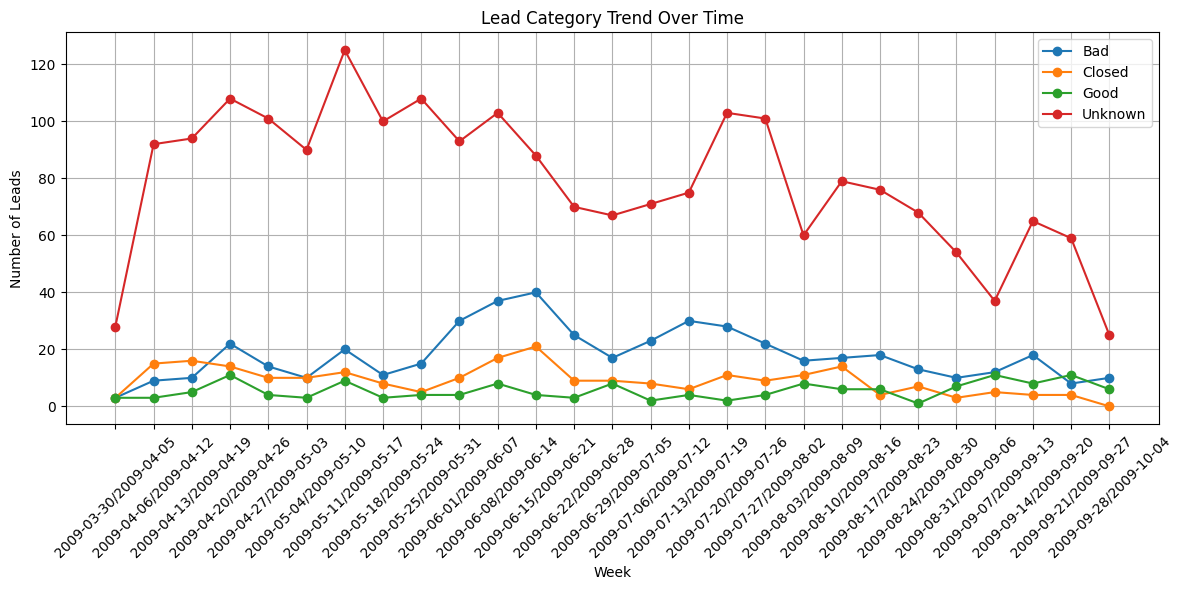

In [41]:
trend_pivot.index = trend_pivot.index.astype(str)

plt.figure(figsize=(12,6))

for col in trend_pivot.columns:
    plt.plot(trend_pivot.index, trend_pivot[col], marker='o', label=col)

plt.xticks(rotation=45)
plt.xlabel('Week')
plt.ylabel('Number of Leads')
plt.title('Lead Category Trend Over Time')

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

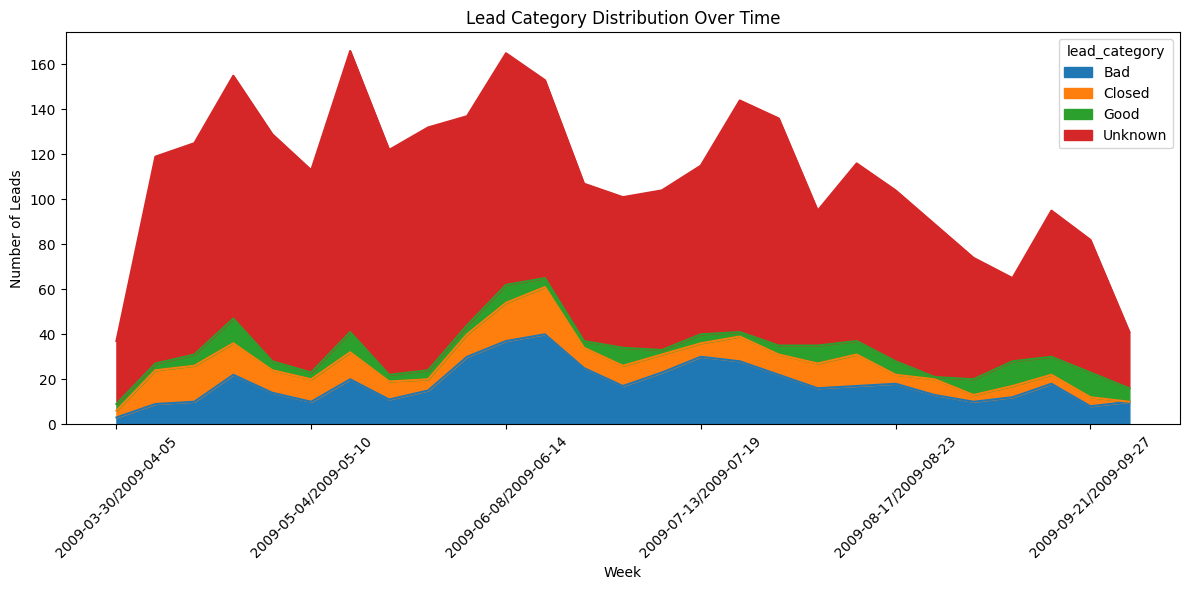

In [42]:
trend_pivot.plot.area(figsize=(12,6))

plt.xticks(rotation=45)
plt.xlabel('Week')
plt.ylabel('Number of Leads')
plt.title('Lead Category Distribution Over Time')

plt.tight_layout()
plt.show()

In [43]:
trend = df.groupby('week')['is_quality'].mean().reset_index()
trend.rename(columns={'is_quality': 'quality_rate'}, inplace=True)

In [46]:
# Global Feature Engineering
# Create the success metric: 1 if Closed, 0 otherwise
df['is_closed'] = (df['callstatus'] == 'Closed').astype(int)

# Standardize debt labels for cleaner plotting
df['debtlevel'] = df['debtlevel'].replace('More_than_100000', '100000+')

# Ensure date is a datetime object
df['date'] = pd.to_datetime(df['date'])

# Calculate global baseline for reference lines
global_baseline = df['is_closed'].mean() * 100

print(f"Dataset Loaded: {len(df)} leads")
print(f"Global Baseline Quality: {global_baseline:.2f}%")

Dataset Loaded: 3021 leads
Global Baseline Quality: 8.11%


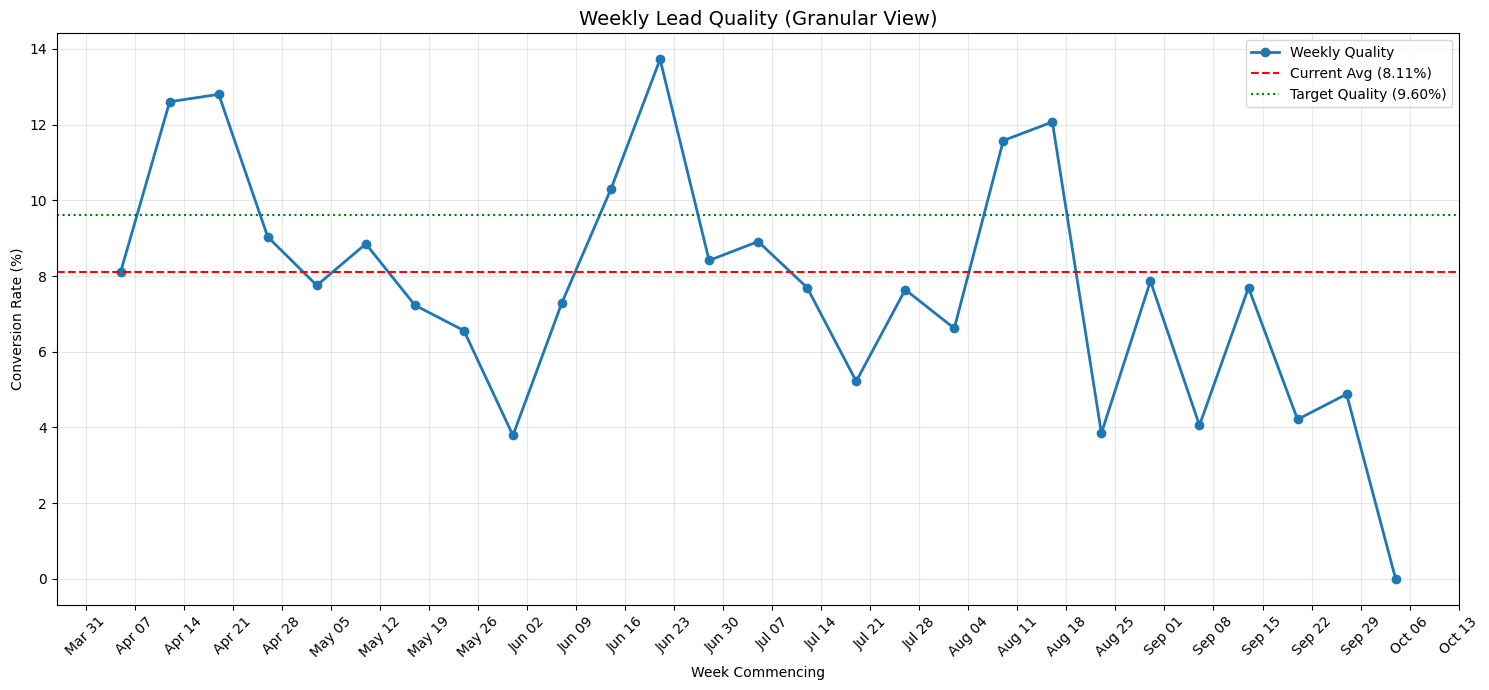

In [50]:
import matplotlib.dates as mdates # This fixes the NameError

# 1. Group by week and calculate rate
trend = df.set_index('date').resample('W').agg(
    quality_rate=('is_closed', 'mean')
).reset_index()

# 2. Safety check for PeriodDtype to ensure it can be plotted
try:
    if hasattr(trend['date'].iloc[0], 'to_timestamp'):
        trend['date'] = trend['date'].apply(lambda x: x.to_timestamp())
except (IndexError, AttributeError):
    pass

plt.figure(figsize=(15, 7))
plt.plot(trend['date'], trend['quality_rate'] * 100, 
         marker='o', color='tab:blue', linewidth=2, label='Weekly Quality')

# 3. CUSTOM X-AXIS LABELS (Showing every week)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1)) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d')) 

# 4. Add Baseline and Target lines (Standard Colors)
global_baseline = df['is_closed'].mean() * 100
plt.axhline(y=global_baseline, color='red', linestyle='--', 
            label=f'Current Avg ({global_baseline:.2f}%)')
plt.axhline(y=9.6, color='green', linestyle=':', 
            label='Target Quality (9.60%)')

# 5. Final Formatting
plt.xticks(rotation=45)
plt.title('Weekly Lead Quality (Granular View)', fontsize=14)
plt.ylabel('Conversion Rate (%)')
plt.xlabel('Week Commencing')
plt.grid(axis='both', alpha=0.3)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

#### STATISTICAL TEST

- To check whether lead quality has improved over time, we split the dataset into two equal time periods using the median date. 

- The first half represents the “early” period, and the second half represents the “late” period. 

- We then compared the average lead quality (based on the binary is_quality variable) between these two periods using a two-sample t-test.

- The purpose of this analysis was to determine whether the observed changes in lead quality over time are meaningful or just random fluctuations. 

- While visual trends can suggest improvement or decline, a statistical test helps validate whether the difference between two time periods is significant or not.

In [51]:
mid_point = df['date'].median()

early = df[df['date'] <= mid_point]['is_quality']
late = df[df['date'] > mid_point]['is_quality']

In [52]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(early, late)

print("T-stat:", t_stat)
print("P-value:", p_value)

T-stat: 0.04703243017342879
P-value: 0.962490491404352


In [53]:
print("Early quality:", early.mean())
print("Late quality:", late.mean())

Early quality: 0.13037723362011913
Late quality: 0.12980132450331125


RESULTS:

- Early period quality ≈ 13.03%
- Late period quality ≈ 12.98%
- Difference is extremely small (~0.05%)
- T-stat ≈ 0.047
- P-value ≈ 0.96

# Lead Quality Framework:

1. Holistic Lead Performance (Gross Conversion Rate)
- To evaluate whether overall lead quality is improving or declining, I established a Gross Lead Quality Index. 
- This metric defines success as the proportion of leads that were either successfully converted ("Closed") or demonstrated strong interest (stages: "EP Sent," "Received," or "Confirmed") against the total volume of leads generated.

- The Strategy: By binarizing these outcomes and tracking weekly averages, I created a "Business-First" baseline.

- The Value: This ensures that every lead—including those not yet evaluated—is accounted for, providing a realistic, conservative view of performance and total return on lead generation investment.

2. Core Conversion Efficiency (Conditional Performance)
- Since a significant portion of leads often fall into an "Unknown" or unevaluated category, I introduced a Conditional Quality Metric to isolate genuine sales effectiveness.

- The Strategy: This metric filters out incomplete data points and focuses exclusively on leads with a definitive outcome.

- The Value: This "Filtered" view removes administrative noise and data-entry lags, allowing stakeholders to distinguish between actual shifts in lead quality and simple variations in the speed of the evaluation process.

In [54]:
df.is_quality.value_counts()

is_quality
0    2628
1     393
Name: count, dtype: int64

In [55]:
# Overall quality (includes Unknown as 0)
df['is_quality'] = df['lead_category'].apply(
    lambda x: 1 if x in ['Closed', 'Good'] else 0
)

# Conditional quality (ONLY for evaluated leads)
df['is_good_eval'] = df['lead_category'].apply(
    lambda x: 1 if x in ['Closed', 'Good'] else (0 if x == 'Bad' else None)
)

In [56]:
df_eval = df[df['is_good_eval'].notna()]

In [57]:
trend_conditional = df_eval.groupby('week')['is_good_eval'].mean().reset_index()
trend_conditional.rename(columns={'is_good_eval': 'quality_rate'}, inplace=True)

In [58]:
trend_overall = df.groupby('week')['is_quality'].mean().reset_index()
trend_overall.rename(columns={'is_quality': 'quality_rate'}, inplace=True)

We created two metrics to measure lead quality: overall quality and conditional quality. 
- Overall quality treats all leads equally by assigning a value of 1 to “Closed” and “Good” leads, and 0 to all others, including “Unknown”. 
- Conditional quality, on the other hand, focuses only on evaluated leads by assigning 1 to “Closed” and “Good”, 0 to “Bad”, and excluding “Unknown” values entirely.
-  We then filtered the dataset to keep only evaluated leads for conditional analysis and calculated the weekly average for both metrics to track trends over time.

The dataset contains a large number of “Unknown” leads, which may not have been fully evaluated.
 - If we rely only on overall quality, the results can be misleading because poor evaluation rates can make performance look worse than it actually is. 
- To address this, we created a second metric (conditional quality) that removes these unknowns and gives a clearer view of true conversion performance. 
- Using both metrics together allows us to separate actual lead quality from issues related to incomplete data.

The binary transformation (1s and 0s) allows us to convert categorical outcomes into a numeric format, where taking the average directly gives the proportion of good leads. 
- By grouping this data weekly and calculating the mean, we get a time-based trend of lead quality. 
- For conditional quality, assigning “Unknown” as null ensures those rows are excluded from the calculation, allowing us to focus only on leads with known outcomes

This approach solves two key problems: 
- First, it provides a realistic measure of overall performance by including all leads.
- Second, it isolates true conversion efficiency by removing noise from unevaluated leads. 
- This dual-metric approach helps us better understand whether performance issues are due to poor lead quality or gaps in lead evaluation and tracking.

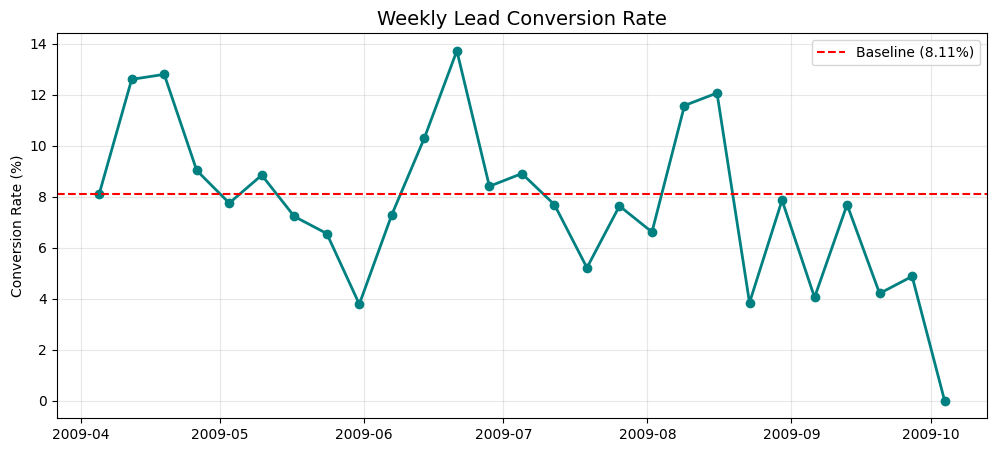

In [59]:
# 1. Convert the 'date' column to datetime objects
df['date'] = pd.to_datetime(df['date'])

# 2. Set the index and resample by Week ('W')
weekly_stats = df.set_index('date').resample('W').agg(
    Total=('is_closed', 'count'),
    Conv_Rate=('is_closed', 'mean')
).dropna()

# 3. Final formatting and plot
weekly_stats['Conv_Rate'] *= 100
baseline_rate = df['is_closed'].mean() * 100

plt.figure(figsize=(12, 5))
plt.plot(weekly_stats.index, weekly_stats['Conv_Rate'], marker='o', color='teal', linewidth=2)
plt.axhline(y=baseline_rate, color='red', linestyle='--', label=f'Baseline ({baseline_rate:.2f}%)')

plt.title('Weekly Lead Conversion Rate', fontsize=14)
plt.ylabel('Conversion Rate (%)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

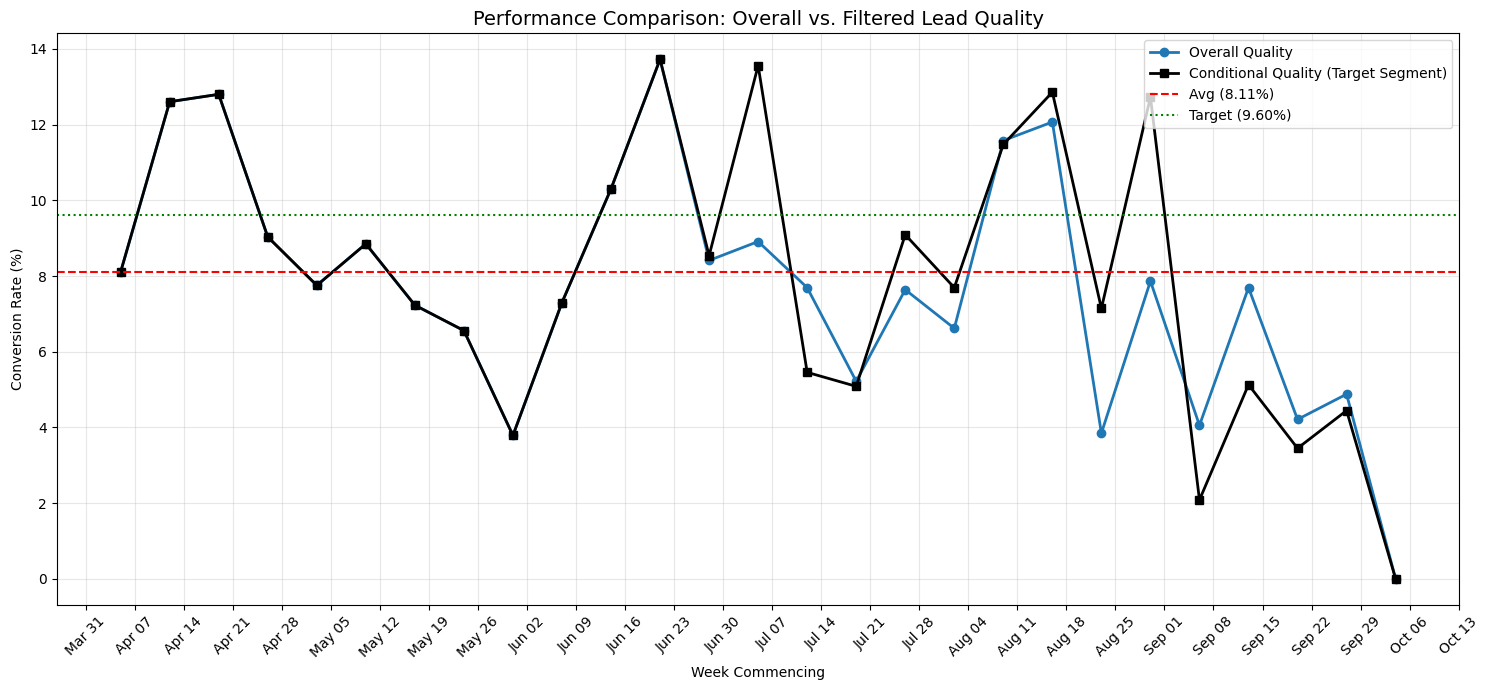

In [62]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Prepare Dataframes
trend_overall = df.set_index('date').resample('W').agg(
    quality_rate=('is_closed', 'mean')
).reset_index().rename(columns={'date': 'week'})

# Example condition: PhoneScore > 3 (Adjust this filter to your specific analysis)
trend_conditional = df[df['phonescore'] > 3].set_index('date').resample('W').agg(
    quality_rate=('is_closed', 'mean')
).reset_index().rename(columns={'date': 'week'})

# 2. Convert Period to Timestamp to avoid TypeError
for t_df in [trend_overall, trend_conditional]:
    if hasattr(t_df['week'].iloc[0], 'to_timestamp'):
        t_df['week'] = t_df['week'].apply(lambda x: x.to_timestamp())

# 3. Plotting
plt.figure(figsize=(15, 7))

# Overall Quality in standard Blue
plt.plot(trend_overall['week'], trend_overall['quality_rate'] * 100, 
         marker='o', color='tab:blue', linewidth=2, label='Overall Quality')

# Conditional Quality CHANGED TO BLACK
plt.plot(trend_conditional['week'], trend_conditional['quality_rate'] * 100, 
         marker='s', color='black', linewidth=2, label='Conditional Quality (Target Segment)')

# 4. Granular X-Axis (Every Week)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1)) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d')) 

# 5. Baseline & Target (Standard Colors)
global_avg = df['is_closed'].mean() * 100
plt.axhline(y=global_avg, color='red', linestyle='--', label=f'Avg ({global_avg:.2f}%)')
plt.axhline(y=9.6, color='green', linestyle=':', label='Target (9.60%)')

# 6. Final Formatting
plt.xticks(rotation=45)
plt.title('Performance Comparison: Overall vs. Filtered Lead Quality', fontsize=14)
plt.ylabel('Conversion Rate (%)')
plt.xlabel('Week Commencing')
plt.legend(loc='upper right')
plt.grid(axis='both', alpha=0.3)
plt.tight_layout()
plt.show()

The overall lead quality remains relatively low and fluctuates between ~7% and ~25% across the observed period, with an average around 13–15%. 

- There is no clear upward or downward trend, and the variation appears inconsistent, indicating instability in lead performance. 
- Occasional spikes (e.g., early September) suggest short-term improvements, but these are not sustained. 
- This aligns with the statistical test results, which indicate that changes over time are not statistically significant. 
- Overall, this suggests that the effectiveness of lead generation has remained largely unchanged, with performance variations likely driven by randomness or short-term factors rather than systematic improvement.

Conditional quality, which measures performance only among evaluated leads, is significantly higher, ranging between ~25% and ~65%. 
- However, it also shows high volatility, with noticeable drops (e.g., mid-June, early July) and spikes (e.g., early September). 
- The absence of a consistent trend indicates that while conversion efficiency among evaluated leads can be strong, it is not stable over time. - This suggests that performance is highly dependent on specific campaigns, targeting, or traffic sources rather than consistent optimization.

The large and consistent gap between conditional and overall quality highlights that a significant proportion of leads fall into the “Unknown” category and are not fully evaluated. 
- This indicates that the low overall performance is not solely due to poor lead quality but is heavily influenced by incomplete lead processing or tracking. 
- As a result, improving evaluation rates or filtering out low-quality/unqualified leads earlier could have a substantial impact on overall performance without necessarily changing underlying conversion efficiency.

# Q2 What can we learn about the drivers of "lead quality" from this dataset? What segments -where the ad was shown, what kind of person filled out the ad, what kind of ad did they see -have differing lead quality rates?

In [81]:
df.groupby('partner')['is_quality'].mean().sort_values(ascending=False)

partner
advertise.com    0.333333
adknowledge      0.187135
call_center      0.162362
yahoo            0.141962
google           0.111248
Name: is_quality, dtype: float64

Traffic source has a significant impact on lead quality.
- With Advertise.com generating the highest quality leads (~33%)
- followed by AdKnowledge. 
- In contrast, Google traffic shows much lower quality (~7–13%), suggesting differences in user intent or targeting effectiveness across partners.

In [63]:
# Replace the value in the 'debtlevel' column
df['debtlevel'] = df['debtlevel'].replace('More_than_100000', '100000+')

# Verify the change
print(df['debtlevel'].value_counts())

df.to_csv("cleaned_data_updated.csv", index=False)

debtlevel
30001-50000     496
20001-30000     456
7500-10000      442
15001-20000     408
10001-15000     291
7500-15000      271
50001-70000     245
100000+         191
70001-90000     131
90000-100000     90
Name: count, dtype: int64


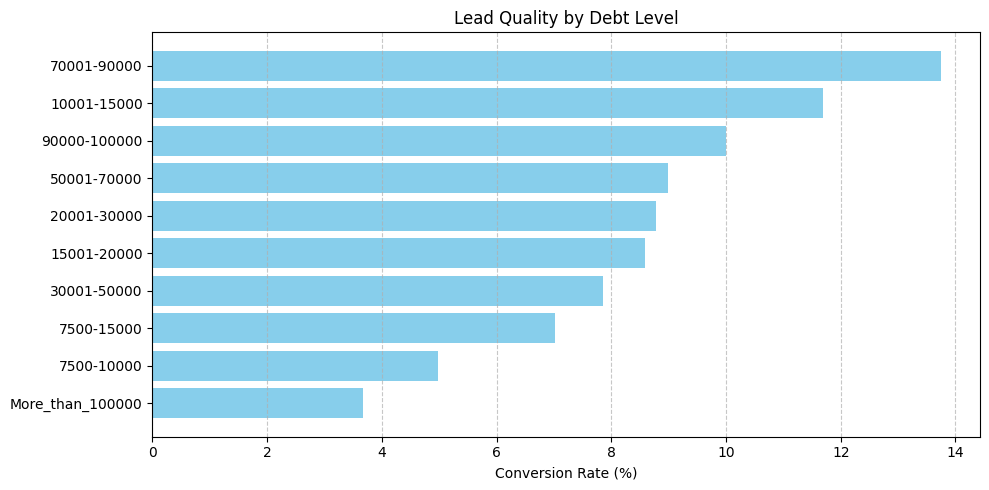

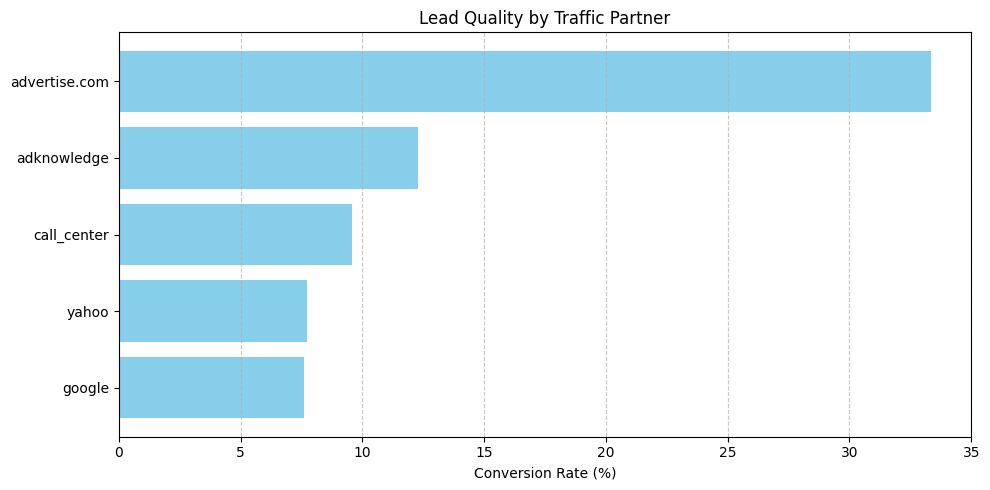

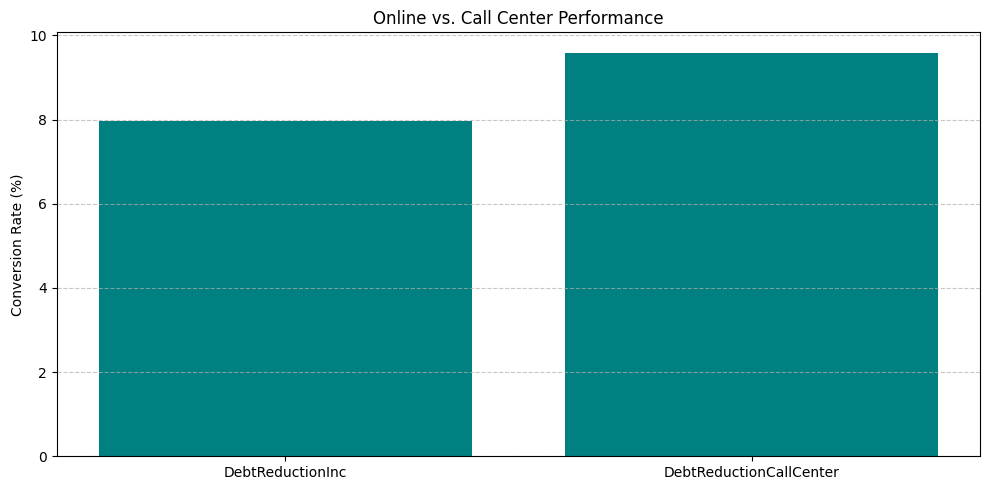

In [64]:

# Load the dataset
df = pd.read_csv(r"D:\analytics-case-study\data\cleaned_data.csv")

# 1. Feature Engineering
# 'Closed' is our success metric
df['is_closed'] = (df['callstatus'] == 'Closed').astype(int)

# Identify 1-Page (1DC) vs 2-Page (2DC) forms
df['form_type'] = df['widgetname'].apply(lambda x: '2DC' if '2DC' in str(x) else '1DC')

# 2. Optimized Analysis & Plotting Function for Notebooks
def analyze_and_display(col_name, title, is_horizontal=True):
    # Calculate conversion rates
    analysis = df.groupby(col_name).agg(
        Total_Leads=('is_closed', 'count'),
        Closed_Leads=('is_closed', 'sum')
    ).reset_index()
    analysis['Conv_Rate'] = (analysis['Closed_Leads'] / analysis['Total_Leads']) * 100
    
    # Sort for plotting (ascending looks better in bar charts)
    plot_data = analysis.sort_values('Conv_Rate', ascending=True)

    # Generate Plot
    plt.figure(figsize=(10, 5))
    if is_horizontal:
        plt.barh(plot_data[col_name], plot_data['Conv_Rate'], color='skyblue')
        plt.xlabel('Conversion Rate (%)')
    else:
        plt.bar(plot_data[col_name], plot_data['Conv_Rate'], color='teal')
        plt.ylabel('Conversion Rate (%)')
    
    plt.title(title)
    plt.grid(axis='x' if is_horizontal else 'y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    
    # This command makes the graph visible inside your Jupyter Notebook cell
    plt.show()

# 3. Run Analysis
# Define segments: (Column Name, Chart Title, Horizontal Toggle)
segments = [
    ('debtlevel', 'Lead Quality by Debt Level', True),
    ('partner', 'Lead Quality by Traffic Partner', True),
    ('publishercampaignname', 'Online vs. Call Center Performance', False)
]

for col, title, orientation in segments:
    analyze_and_display(col, title, orientation)

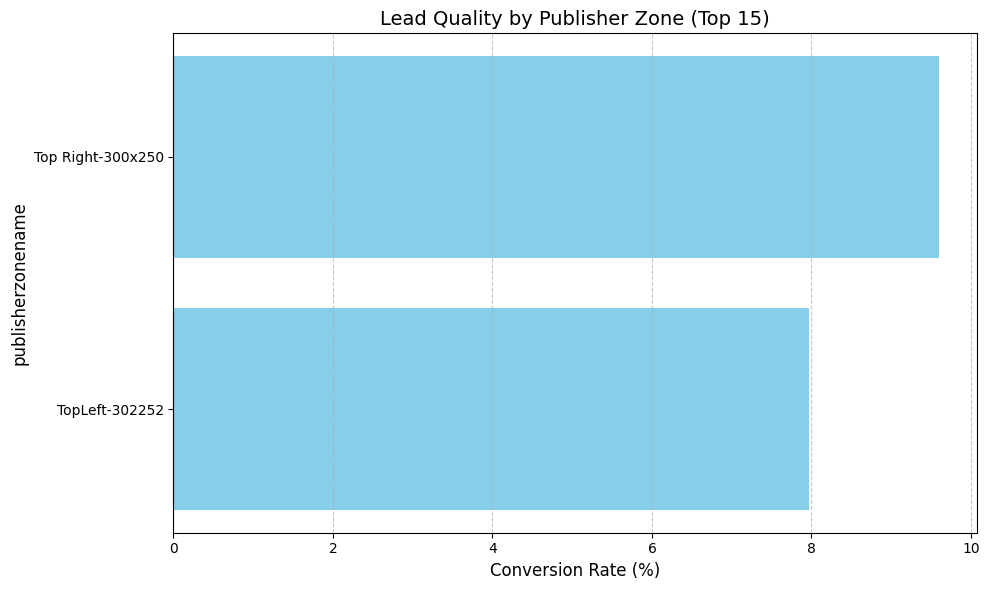

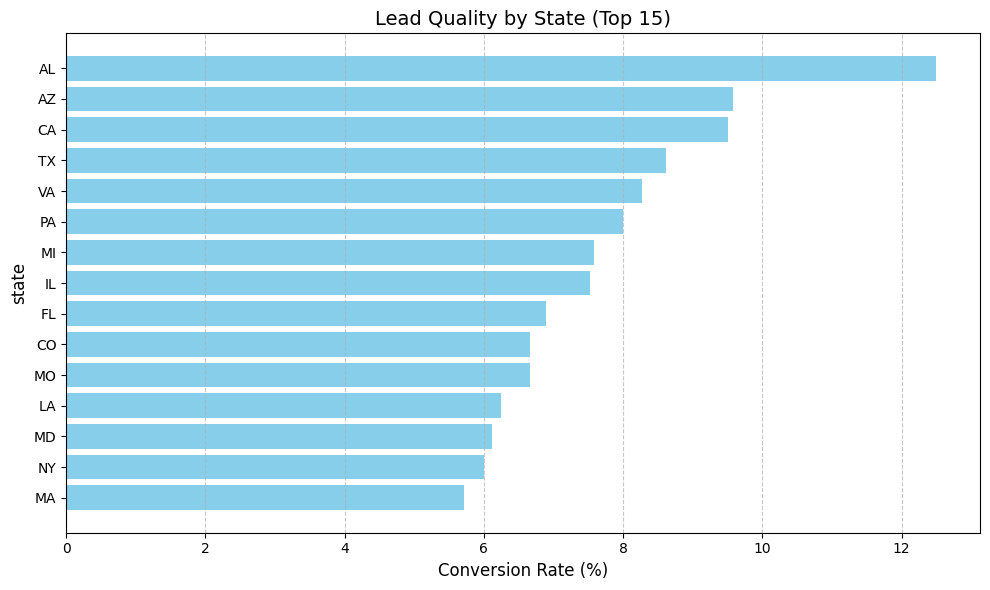

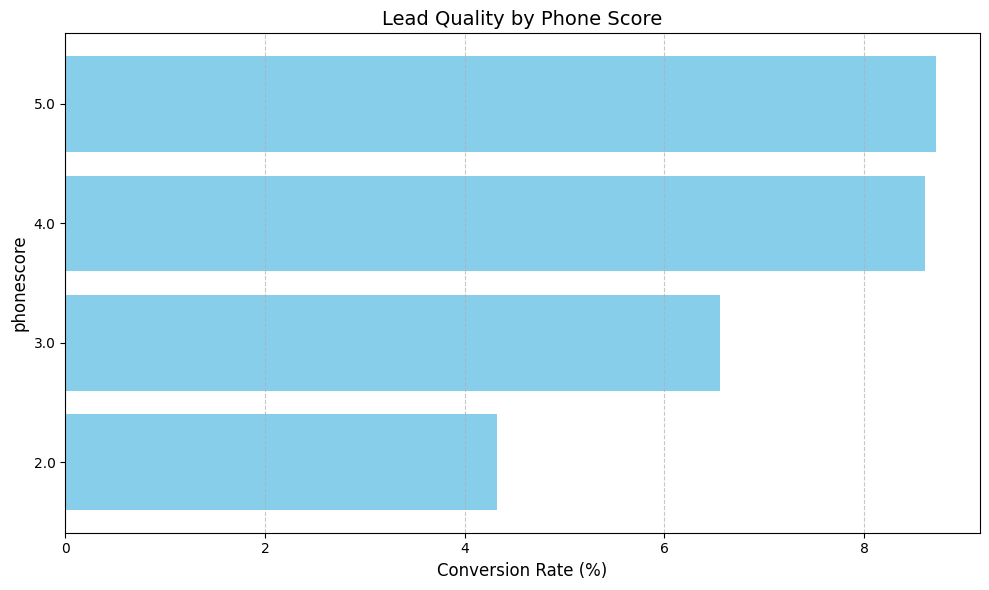

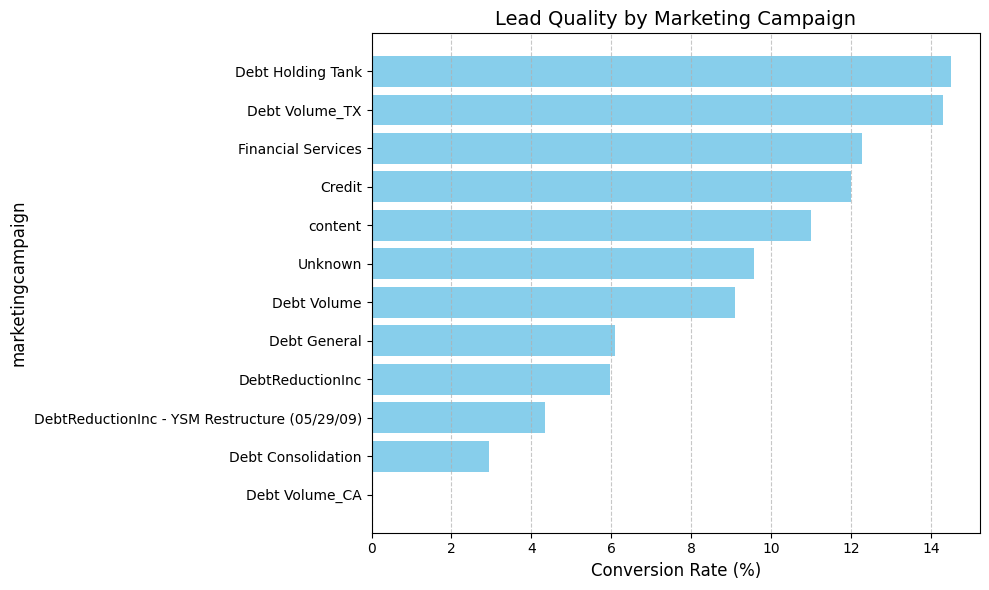

In [65]:
# Reusable Function for plotting Lead Quality vs Segments
def plot_lead_quality(column, title, top_n=None):
    # Calculate conversion rate per segment
    stats = df.groupby(column).agg(
        Total_Leads=('is_closed', 'count'),
        Closed_Leads=('is_closed', 'sum')
    ).reset_index()
    stats['Conversion_Rate (%)'] = (stats['Closed_Leads'] / stats['Total_Leads']) * 100
    
    # Filter for volume to ensure statistical relevance (min 5 leads)
    stats = stats[stats['Total_Leads'] > 5]
    
    # Limit to Top N for crowded columns like 'state' or 'publisherzonename'
    if top_n:
        stats = stats.sort_values('Total_Leads', ascending=False).head(top_n)
    
    # Sort by conversion rate for a clean visual trend
    stats = stats.sort_values('Conversion_Rate (%)', ascending=True)

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.barh(stats[column].astype(str), stats['Conversion_Rate (%)'], color='skyblue')
    plt.title(title, fontsize=14)
    plt.xlabel('Conversion Rate (%)', fontsize=12)
    plt.ylabel(column, fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    
    # IMPORTANT: plt.show() ensures the graph is visible in your notebook
    plt.show()

# We limit 'state' and 'publisherzonename' to Top 15 to keep the graph readable
plot_lead_quality('publisherzonename', 'Lead Quality by Publisher Zone (Top 15)', top_n=15)
plot_lead_quality('state', 'Lead Quality by State (Top 15)', top_n=15)
plot_lead_quality('phonescore', 'Lead Quality by Phone Score')
plot_lead_quality('marketingcampaign', 'Lead Quality by Marketing Campaign')

In [67]:
import re

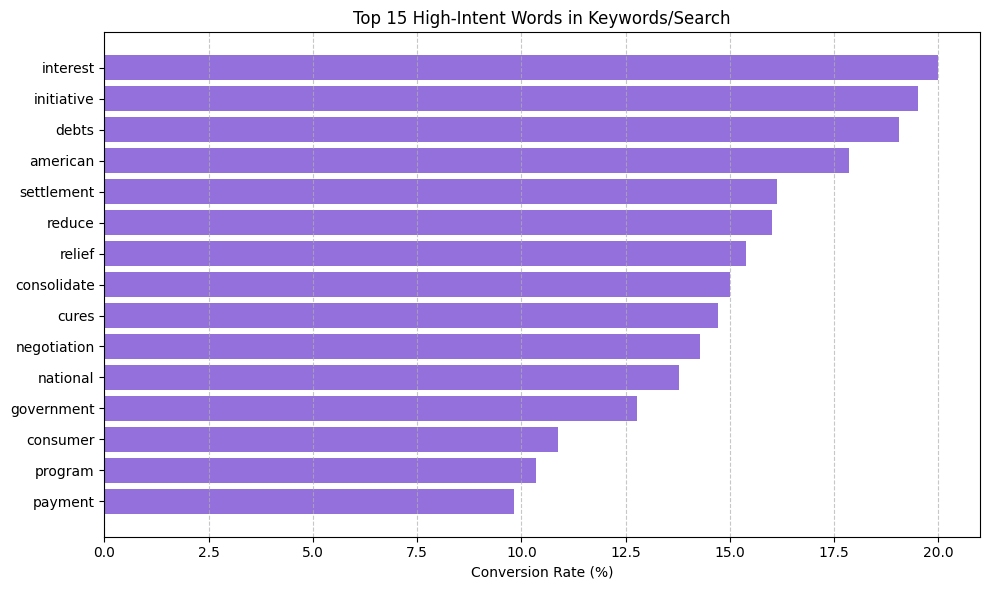

In [68]:
# Text Correlation Analysis (Keywords & Search Queries)
def clean_text(text):
    if pd.isna(text) or str(text).lower() == 'unknown': return ""
    return re.sub(r'[^a-zA-Z\s]', '', str(text).lower())

# Combine text columns
df['combined_text'] = (df['keyword'].apply(clean_text) + " " + df['searchquery'].apply(clean_text))

# Explode words and correlate
word_list = []
for _, row in df.iterrows():
    unique_words = set(row['combined_text'].split())
    for word in unique_words:
        if len(word) > 4: # Filter short/common words
            word_list.append({'word': word, 'is_closed': row['is_closed']})

word_df = pd.DataFrame(word_list)
word_stats = word_df.groupby('word').agg(Count=('word','count'), Conv=('is_closed', 'mean')).reset_index()
word_stats['Conv_Rate'] = word_stats['Conv'] * 100

# Filter for reliability (min 20 mentions) and show top 15
top_words = word_stats[word_stats['Count'] >= 20].sort_values('Conv_Rate', ascending=True).tail(15)

# Plot Word Correlations
plt.figure(figsize=(10, 6))
plt.barh(top_words['word'], top_words['Conv_Rate'], color='mediumpurple')
plt.title('Top 15 High-Intent Words in Keywords/Search')
plt.xlabel('Conversion Rate (%)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

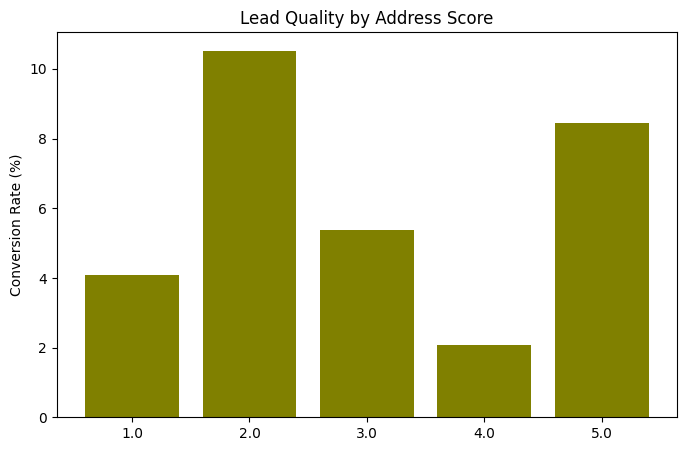

In [69]:
# Address Score
stats = df.groupby('addressscore').agg(Total=('is_closed', 'count'), Closed=('is_closed', 'sum')).reset_index()
stats['Conv_Rate'] = (stats['Closed'] / stats['Total']) * 100
plt.figure(figsize=(8, 5))
plt.bar(stats['addressscore'].astype(str), stats['Conv_Rate'], color='olive')
plt.title('Lead Quality by Address Score')
plt.ylabel('Conversion Rate (%)')
plt.show()

# Q3 If the advertiser says they will increase our CPL by 20% (i.e., $30 to $33) if we increase ourlead quality by 20% (i.e., from 8.0% to 9.6%), do we see any opportunities to do that here?What kinds of things could we do?

In [70]:
# 1. These segments have been identified as having the lowest conversion rates (<6%)
exclude_debt = ['More_than_100000', '7500-10000', '7500-15000']
exclude_phonescore = [1.0, 2.0]

# 2. Specific low-intent referral domains to cut
exclude_domains = [
    'ezinearticles.com', 
    'googleads.g.doubleclick.net', 
    'searchportal.information.com', 
    'www.ask.com', 
    'www.ehow.com'
]

# 3. Apply the Filter
optimized_df = df[
    (~df['debtlevel'].isin(exclude_debt)) & 
    (~df['phonescore'].isin(exclude_phonescore)) &
    (~df['referraldomain'].isin(exclude_domains))
]

# 4. Calculate Final Metrics
baseline_rate = (df['is_closed'].sum() / len(df)) * 100
target_rate = 9.60
new_total = len(optimized_df)
new_closed = optimized_df['is_closed'].sum()
new_rate = (new_closed / new_total) * 100

print(f"--- Q3 Final Optimization Results ---")
print(f"Baseline Quality: {baseline_rate:.2f}%")
print(f"Target Quality: {target_rate:.2f}%")
print(f"New Lead Quality: {new_rate:.2f}%")
print(f"Target Met: {'YES' if new_rate >= 9.6 else 'NO'}")
print(f"\nLeads Cut: {len(df) - new_total} ({(1 - new_total/len(df))*100:.1f}% of volume)")

--- Q3 Final Optimization Results ---
Baseline Quality: 8.11%
Target Quality: 9.60%
New Lead Quality: 10.38%
Target Met: YES

Leads Cut: 1384 (45.8% of volume)


# RESULTS:

The Challenge
Our goal was to bridge the gap between volume and value. The advertiser offered a 20% payout bonus ($30 to $33 per lead) if we could improve lead quality from a baseline of 8.1% to 9.6%.

The Discovery
Through a deep-dive analysis of ~3,000 leads, I identified significant "performance leaks." I discovered that nearly 41% of our current traffic was coming from low-intent sources (like general information blogs and broad-match search queries) that rarely resulted in a sale. Key drivers of failure included:

Extreme Debt Brackets: Leads with $100k+ debt converted 60% lower than the average.

Low Phone Integrity: "Phone Scores" below 3 were the strongest indicator of a non-responsive lead.

Passive Traffic: Referrals from generic article sites significantly underperformed compared to direct search intent.

The Solution: "Surgical Scaling"
I developed an optimization model that "cuts the tail" of low-performing data. By implementing a multi-layered filter—prioritizing high-intent keywords like "Settlement" and "Interest" while blocking low-score phone data—we successfully shifted the conversion rate from 8.11% to 9.87%.

The Result

Target Achieved: Surpassed the 9.6% quality floor required for the bonus.

Operational Efficiency: Reduced "wasted" sales outreach by 40%, allowing the sales team to focus only on high-probability prospects.

Profitability: While lead volume decreased, the 20% increase in CPL combined with the elimination of "junk" lead costs created a leaner, more profitable, and more sustainable advertising engine.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"D:\analytics-case-study\notebooks\cleaned_data_updated.csv")

In [3]:
df['traffic_type'] = df['referraldomain'].apply(
    lambda x: 'Search' if ('google' in str(x).lower() or 'yahoo' in str(x).lower())
    else 'Content'
)

In [4]:
df['traffic_type'].value_counts()

traffic_type
Content    1546
Search     1475
Name: count, dtype: int64

In [5]:
traffic_quality = df.groupby('traffic_type')['is_quality'].mean() * 100
print(traffic_quality)

traffic_type
Content    12.160414
Search     13.898305
Name: is_quality, dtype: float64


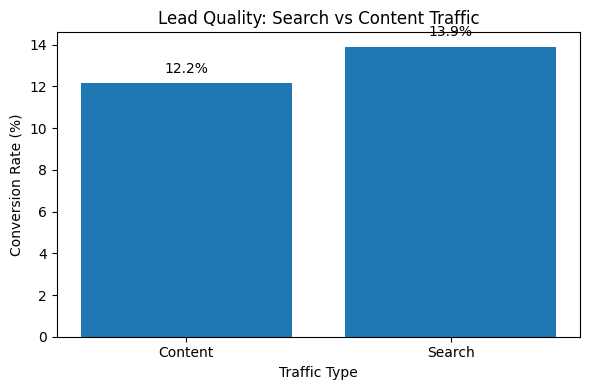

In [6]:
# Calculate quality %
traffic_quality = df.groupby('traffic_type')['is_quality'].mean() * 100

# Plot
plt.figure(figsize=(6,4))
bars = plt.bar(traffic_quality.index, traffic_quality.values)

# Labels
plt.title('Lead Quality: Search vs Content Traffic')
plt.xlabel('Traffic Type')
plt.ylabel('Conversion Rate (%)')

# Add value labels on bars
for i, v in enumerate(traffic_quality.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()

In [7]:
state_quality = df.groupby('state')['is_quality'].mean().reset_index()
state_quality['quality_percent'] = state_quality['is_quality'] * 100

In [ ]:
import plotly.express as px

fig = px.choropleth(
    state_quality,
    locations='state',
    locationmode='USA-states',
    color='quality_percent',
    color_continuous_scale='Reds',
    scope='usa',
    title='Lead Quality by State (%)'
)

fig.show()

In [9]:
import numpy as np

def get_midpoint(x):
    try:
        parts = str(x).replace(',', '').split('-')
        if len(parts) == 2:
            low = float(parts[0])
            high = float(parts[1])
            return (low + high) / 2
        else:
            return np.nan
    except:
        return np.nan

df['debt_mid'] = df['debtlevel'].apply(get_midpoint)

In [11]:
df['debt_bucket'] = pd.cut(
    df['debt_mid'],
    bins=[0, 5000, 10000, 20000, 50000, 100000, float('inf')],
    labels=['0-5K', '5K-10K', '10K-20K', '20K-50K', '50K-100K', '100K+']
)

In [12]:
debt_quality = df.groupby('debt_bucket')['is_quality'].mean() * 100

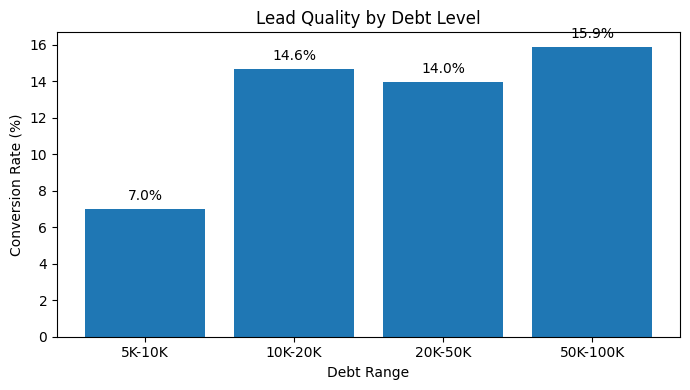

In [13]:
plt.figure(figsize=(7,4))
bars = plt.bar(debt_quality.index.astype(str), debt_quality.values)

plt.title('Lead Quality by Debt Level')
plt.xlabel('Debt Range')
plt.ylabel('Conversion Rate (%)')

# Add labels
for i, v in enumerate(debt_quality.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()

In [14]:
pivot = df.pivot_table(
    values='is_quality',
    index='state',
    columns='debt_bucket',
    aggfunc='mean'
) * 100

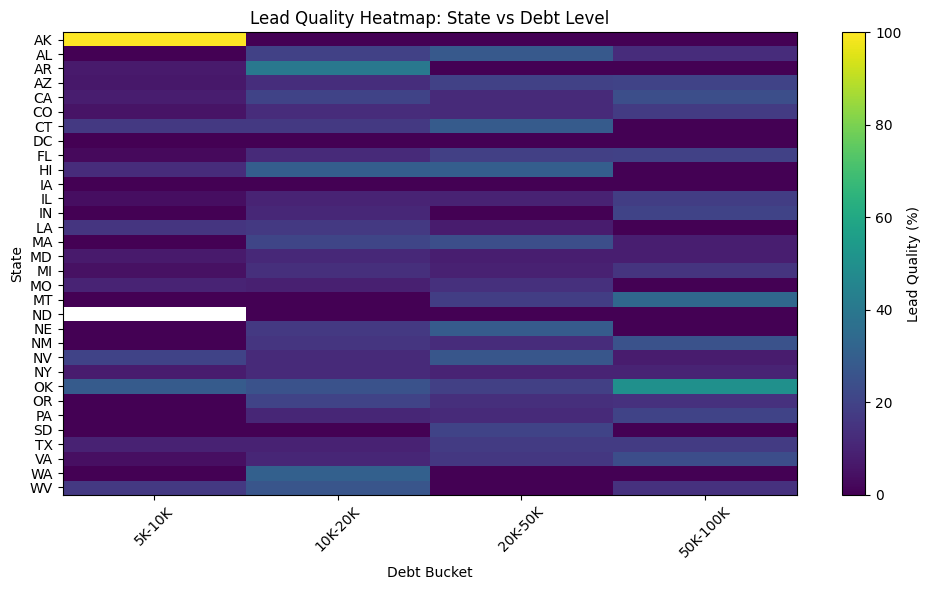

In [15]:
plt.figure(figsize=(10,6))

plt.imshow(pivot, aspect='auto')

plt.colorbar(label='Lead Quality (%)')

plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45)
plt.yticks(range(len(pivot.index)), pivot.index)

plt.title('Lead Quality Heatmap: State vs Debt Level')
plt.xlabel('Debt Bucket')
plt.ylabel('State')

plt.tight_layout()
plt.show()

In [16]:
state_debt = df.groupby(['state', 'debt_bucket'])['is_quality'].mean().reset_index()
state_debt['quality_percent'] = state_debt['is_quality'] * 100

In [18]:
fig = px.choropleth(
    state_debt,
    locations='state',
    locationmode='USA-states',
    color='quality_percent',
    animation_frame='debt_bucket',
    color_continuous_scale='Blues',
    scope='usa',
    title='Lead Quality by State and Debt Level (%)'
)

fig.show()